# Hydro Modelling
Hydro generators are modelled using plant data from __[CODERS](https://coders.cme-emh.ca/login)__, river basin data from __[MERIT](https://hydro.iis.u-tokyo.ac.jp/~yamadai/MERIT_Hydro/index.html)__ and river discharge data from __[GRFR](https://www.reachhydro.org/home/records/grfr)__.

In [1]:
import pandas as pd
import geopandas as gpd
import os
import netCDF4 as nc
import matplotlib.pyplot as plt
import requests

from helper_functions import mapPoints, download_and_unzip

In [2]:
province_map = {
'Newfoundland and Labrador':'NL',
'Prince Edward Island':'PE',
'Nova Scotia':'NS',
'New Brunswick':'NB',
'Quebec':'QC',
'Ontario':'ON',
'Manitoba':'MB',
'Saskatchewan':'SK',
'Alberta':'AB',
'British Columbia':'BC',
}

month_map = {
    'Jan':1,
    'Feb':2,
    'Mar':3,
    'Apr':4,
    'May':5,
    'Jun':6,
    'Jul':7,
    'Aug':8,
    'Sep':9,
    'Oct':10,
    'Nov':11,
    'Dec':12
}

## Loading Data

In [3]:
### Loading Data
path = os.getcwd()
data_path = os.path.join(path, 'data')
os.makedirs(os.path.join(data_path, 'map_files', 'MERIT_basin'), exist_ok=True)

# CODERS generator data
hydro_generators = pd.read_csv(os.path.join(data_path, 'CODERS', 'generators.csv'))
hydro_generators = hydro_generators[hydro_generators.gen_type.str.contains('hydro_')]
hydro_generators = hydro_generators.groupby(['generation_facility_name', 'gen_type']).first()
hydro_generators = hydro_generators.reset_index()[['generation_facility_name', 'gen_type', 'facility_average_annual_energy', 'province', 'latitude', 'longitude', 'facility_installed_capacity', 'start_year']]
hydro_generators = hydro_generators.rename(columns={'generation_facility_name':'name', 'facility_average_annual_energy':'annual_energy', 'facility_installed_capacity':'capacity'})

hydro_generators = mapPoints(hydro_generators).to_crs('EPSG: 3347')

# Reading cluster data
clusters = gpd.read_feather(os.path.join(path, 'results', 'clustered_zone_data.feather')).to_crs('EPSG: 3347')
clusters = clusters[['geometry']]

# Finding cluster
hydro_generators = hydro_generators.sjoin_nearest(clusters, how='left').set_index('name')
hydro_generators.to_csv(os.path.join(path, 'results', 'intermediary_outputs', 'hydro_units.csv'))
hydro_generators.head()

c:\Users\ndematos\envs\update_pypsa_canada_py312\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\ndematos\envs\update_pypsa_canada_py312\Lib\site-packages\geopandas\io\arrow.py:878: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  table = feather.read_table(path, columns=columns, **kwargs)


,gen_type,annual_energy,province,latitude,longitude,capacity,start_year,geometry,cluster
name,,,,,,,,,
Aberfeldie,hydro_daily,69.62,BC,49.493319,-115.362424,24.0,2009,POINT (4539396.182 1794045.156),BC_South
Abitibi Canyon,hydro_daily,877.08,ON,49.882200,-81.567000,355.0,1933,POINT (6934563.806 1586543.954),ON_North
AbÃ©naquis,hydro_run,13.80,QC,45.405156,-71.893197,2.1,1910,POINT (7761964.416 1273618.676),QC_East
Adam-Cunningham,hydro_daily,36.00,QC,48.658081,-71.170801,7.0,1953,POINT (7699937.054 1637136.192),QC_Central
Aguasabon,hydro_daily,102.09,ON,48.786700,-87.161000,52.0,1948,POINT (6545762.071 1418053.391),ON_Northwest


### Assigning river
The first step is filtering the run of river hydro plants from CODERS and matching them to the closest MERIT river basin. The basin data used is the shapefile from the north-american (pfaf_7) portion of the __[MERIT dataset](https://drive.google.com/drive/folders/1FAZ70JTeDfz8O6wKgqiTPXWX-wy44XwR)__. Download all the riv_pfaf_7_MERIT_Hydro_v07_Basins_v01 files and place them in data/map_files/MERIT_basin

In [4]:
basins = gpd.read_file(os.path.join(path, 'data', 'map_files', 'MERIT_basin', 'riv_pfaf_7_MERIT_Hydro_v07_Basins_v01.shp'))
basins = gpd.GeoDataFrame(basins, geometry=basins.geometry, index=basins.index, crs='EPSG:4326')

# Filtering out all rivers outside of Canada
def filter_lat(line):
    return any(coord[1] >= 41.681389 for coord in line.coords)
    
basins = basins[basins['geometry'].apply(lambda geom: filter_lat(geom))]
basins = basins.to_crs('EPSG: 3347')
basins.head()

,COMID,lengthkm,lengthdir,sinuosity,slope,uparea,order,strmDrop_t,slope_taud,NextDownID,maxup,up1,up2,up3,up4,geometry
0,71000001,7.020492,4.158236,1.688334,0.000570,391.888582,2,0.0,0.000000,71000029,2,71000033,71000047,0,0,"LINESTRING (5864525.144 2649628.852, 5864471.3..."
1,71000002,24.171249,15.709184,1.538670,0.000058,701.729073,2,1.4,0.000058,71000029,2,71000003,71000014,0,0,"LINESTRING (5864525.144 2649628.852, 5864578.9..."
2,71000003,14.760464,11.209022,1.316838,0.000770,480.739118,2,11.4,0.000770,71000002,2,71000004,71000011,0,0,"LINESTRING (5859936.059 2664226.766, 5859882.3..."
3,71000004,6.240078,4.631999,1.347168,0.000911,388.921733,2,5.7,0.000911,71000003,2,71000005,71000015,0,0,"LINESTRING (5850542.97 2658643.318, 5850507.26..."
4,71000005,4.462477,3.338111,1.336827,0.000670,328.548919,2,3.0,0.000670,71000004,2,71000006,71000012,0,0,"LINESTRING (5847384.491 2661869.969, 5847330.4..."


In [5]:
DATA_YEAR = 2019
MODEL_YEAR = 2025

## Download files
os.makedirs(os.path.join(data_path, 'GRFR'), exist_ok=True)
GRFR_file = f"output_pfaf_07_{DATA_YEAR}.nc"
if os.path.exists(os.path.join(data_path, 'GRFR', GRFR_file)):
    print(f"GRFR data for {DATA_YEAR} already downloaded, skipping")
else:
    url = f"https://g-9d078a.0f1d28.a567.data.globus.org/{GRFR_file}"
    response = requests.get(url) 
    
    with open(os.path.join(data_path, 'GRFR', GRFR_file), "wb") as f:
        f.write(response.content)

# Getting profiles from GFRF data
flow_data = nc.Dataset(os.path.join(data_path, 'GRFR', GRFR_file))

GRFR data for 2019 already downloaded, skipping


In [6]:
# Run of river generators
ror_gens = hydro_generators[hydro_generators.gen_type.isin(['hydro_run'])]

### Assigning run of river reservoir to nearest basin
ror_gens = gpd.sjoin_nearest(ror_gens, basins[['COMID', 'geometry']], how='left', distance_col='distance')

After assigning each generator to a river, the discharge data from the GRFR database is up-sampled from 3h resolution to hourly, interpolating between the points. A binary search is also conducted, to find the maximum flow associated with maximum power output of the generator (i.e. converting water flow to power). This is done to ensure the total maximum output is equal to the historical production of each plant.

In [7]:
### Calculating ror hydro generator capacity factor series
dates = pd.date_range(f'{MODEL_YEAR}-01-01', periods=2920, freq='3h')
ror_cf = {}
unscaled_ror_cf = {}
for gen, data in ror_gens.iterrows():
    rivids = flow_data.variables['rivid'][:]
    idx = (rivids == data.COMID).nonzero()[0][0]

    generator_data = pd.Series(flow_data.variables['Qout'][:, idx], index=dates)
    generator_data = generator_data.resample('1h').interpolate('linear')
    # Temporary fix, because there is nothing to interpolate last point to
    generator_data[f'{MODEL_YEAR}-12-31 22:00:00'] = generator_data.iloc[-1]
    generator_data[f'{MODEL_YEAR}-12-31 23:00:00'] = generator_data.iloc[-1]
    unscaled_ror_cf[gen] = generator_data.copy()
    rated_capacity = data.capacity
    target_energy = data.annual_energy

    max_possible_energy = (len(generator_data) * rated_capacity) / 1000

    # Binary search bounds and precision
    low, high = 0, (3 * generator_data.max())
    tolerance = 1e-3

    # Binary search to find max flow
    for _ in range(1000):
        mid = (low + high) / 2
        cf = generator_data.divide(mid + 1e-9).clip(upper=1)
        scaled_energy = cf.multiply(rated_capacity)
        energy = scaled_energy.sum() / 1000
        if abs(energy - target_energy) < tolerance:
            break
        if energy > target_energy:
            low = mid # Energy is too high, increase the max flow
        else:
            high = mid # Energy is too low, decrease the max flow

    max_flow = mid
    ror_cf[gen] = scaled_energy
    ror_gens.loc[gen, 'calculated_energy'] = energy
    ror_gens.loc[gen, 'max_flow'] = max_flow

ror_cf = pd.DataFrame.from_dict(ror_cf)
ror_cf = ror_cf.clip(0) # remove negative values
unscaled_ror_cf = pd.DataFrame.from_dict(unscaled_ror_cf)
ror_cf

,AbÃ©naquis,Akolkolex,Alexander,Andrews,Annapolis Tidal,Appleton Eco Power Centre,Ashlu Creek,Auburn,Ayers 1,Ayers 2,...,Wawatay,Wedgemount Creek,Weedon,Westbury,White Otter Falls,Whitedog Falls,Winchie Creek,Windsor,Winston,Yellow Falls
2025-01-01 00:00:00,1.135283,0.704368,23.231007,8.675373,1.552324,0.365730,15.366461,0.591243,0.793863,0.233530,...,2.309282,0.575373,3.019229,2.828629,1.328397,7.826442,3.058136,3.162440,0.404529,3.039636
2025-01-01 01:00:00,1.126041,0.704252,23.213373,8.671472,1.545925,0.365607,15.318069,0.593578,0.787563,0.231676,...,2.309026,0.574161,3.015602,2.828825,1.328021,7.829388,3.040599,3.165874,0.405040,3.039473
2025-01-01 02:00:00,1.116800,0.704136,23.195744,8.667570,1.539526,0.365485,15.269678,0.595912,0.781263,0.229823,...,2.308770,0.572949,3.011976,2.829021,1.327645,7.832333,3.023064,3.169308,0.405551,3.039310
2025-01-01 03:00:00,1.107558,0.704019,23.178112,8.663669,1.533128,0.365362,15.221287,0.598247,0.774963,0.227970,...,2.308514,0.571737,3.008349,2.829216,1.327269,7.835278,3.005527,3.172743,0.406062,3.039147
2025-01-01 04:00:00,1.112285,0.703835,23.160635,8.659656,1.524236,0.367719,15.178112,0.601577,0.864941,0.254439,...,2.308310,0.570651,3.027576,2.859814,1.326908,7.837352,2.989696,3.214624,0.406523,3.038983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,1.716364,0.772591,17.533030,10.664547,1.374114,0.413966,49.900002,0.731494,3.400000,1.000000,...,2.784209,2.589118,2.991139,2.869318,0.731295,9.202355,4.000000,3.862495,2.500000,1.465947
2025-12-31 20:00:00,1.709609,0.812612,17.530581,10.658946,1.384127,0.417268,49.900002,0.731394,3.400000,1.000000,...,2.781132,2.945126,2.976076,2.858808,0.732375,9.200550,4.000000,3.854421,2.500000,1.470938
2025-12-31 21:00:00,1.702854,0.852634,17.528130,10.653345,1.394141,0.420570,49.900002,0.731293,3.400000,1.000000,...,2.778056,3.301135,2.961013,2.848298,0.733455,9.198744,4.000000,3.846346,2.500000,1.475928
2025-12-31 22:00:00,1.702854,0.852634,17.528130,10.653345,1.394141,0.420570,49.900002,0.731293,3.400000,1.000000,...,2.778056,3.301135,2.961013,2.848298,0.733455,9.198744,4.000000,3.846346,2.500000,1.475928


### Saving RoR results
If GROUPED = TRUE, the RoR plants are aggregated based on their cluster. If false, they are kept as individual units.

In [8]:
GROUPED = True

if GROUPED:
    grouped_ror = ror_gens.groupby(['cluster'])['capacity'].sum().reset_index()
    grouped_ror.index = grouped_ror.cluster + '_hydro_run'
    name_map = (ror_gens.cluster + '_hydro_run').to_dict()
else:
    grouped_ror = ror_gens.copy()
    name_map = {idx: f"{idx}_hydro_run" for idx in grouped_ror.index}
    grouped_ror = grouped_ror.set_index(grouped_ror.index + '_hydro_run')

grouped_ror = grouped_ror.rename(columns={'capacity':'p_nom', 'cluster':'bus'})

grouped_ror['build_year'] = 0
grouped_ror['model'] = 'hydro_ror'
grouped_ror['group'] = 'ungrouped'
grouped_ror['p_nom_extendable'] = False

# Non-extendable for existing generators
grouped_ror['p_nom_extendable'] = False

grouped_ror = grouped_ror[['bus', 'model', 'group', 'p_nom', 'p_nom_extendable', 'build_year']]
grouped_ror.to_csv(os.path.join(path, 'results', 'ror_gens.csv'))

grouped_ror_cf = ror_cf.rename(columns=name_map)
grouped_ror_cf = grouped_ror_cf.T.groupby(level=0).sum().T.divide(grouped_ror.p_nom).round(4)
grouped_ror_cf.to_csv(os.path.join(path, 'results', 'ror_cf.csv'))

print(grouped_ror.head())
print(grouped_ror_cf.head())

                             bus      model      group    p_nom  \
cluster                                                           
AB_Central_hydro_run  AB_Central  hydro_ror  ungrouped    16.80   
AB_South_hydro_run      AB_South  hydro_ror  ungrouped   129.60   
BC_North_hydro_run      BC_North  hydro_ror  ungrouped   319.60   
BC_South_hydro_run      BC_South  hydro_ror  ungrouped  1482.42   
MB_hydro_run                  MB  hydro_ror  ungrouped    10.00   

                      p_nom_extendable  build_year  
cluster                                             
AB_Central_hydro_run             False           0  
AB_South_hydro_run               False           0  
BC_North_hydro_run               False           0  
BC_South_hydro_run               False           0  
MB_hydro_run                     False           0  
                     AB_Central_hydro_run  AB_South_hydro_run  \
2025-01-01 00:00:00                0.0482              0.0243   
2025-01-01 01:00:00          

## Reservoir hydro
Reservoir hydro is modelled on a monthly timescale, with an assumed infinite reservoir capacity. The monthly inflows per province are scaled to match __[Historical Data from StatsCan](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=2510001501)__.The generators are aggregated by cluster and modeled as storage units in pypsa.

In [9]:
## Download files
os.makedirs(os.path.join(data_path, 'statscan_powergen'), exist_ok=True)
link = "https://www150.statcan.gc.ca/n1/tbl/csv/25100015-eng.zip"
filepath = os.path.join(data_path, 'statscan_powergen.zip')
outpath = os.path.join(data_path, 'statscan_powergen')
download_and_unzip(link, filepath, outpath)

c:\Users\ndematos\Desktop\pypsa_canada\PyPSA-Canada-National\data\statscan_powergen.zip already exists. Skipping download.


In [10]:
# Reservoir generators
hydro_output = pd.read_csv(os.path.join(path, 'data', 'statscan_powergen', '25100015.csv'), usecols=['REF_DATE', 
                                                                                                     'GEO', 
                                                                                                     'Class of electricity producer', 
                                                                                                     'Type of electricity generation',
                                                                                                     'VALUE'])
hydro_output = hydro_output[hydro_output['Class of electricity producer'] == 'Total all classes of electricity producer']
hydro_output = hydro_output[hydro_output['Type of electricity generation'] == 'Hydraulic turbine']
# Filter by year
hydro_output = hydro_output[hydro_output.REF_DATE.str.contains(str(DATA_YEAR))]
hydro_output['province'] = hydro_output.GEO.map(province_map)
hydro_output = hydro_output[~hydro_output.province.isna()]
hydro_output = hydro_output[['REF_DATE', 'province', 'VALUE']]
hydro_output['year'] = str(MODEL_YEAR)

hydro_output.index = pd.to_datetime({'year': hydro_output['year'], 'month':hydro_output.REF_DATE.str[-2:], 'day':1})
start_date = hydro_output.index.min()
end_date = hydro_output.index.max() + pd.offsets.MonthEnd(0)

res_gens = hydro_generators[hydro_generators.gen_type.isin(['hydro_daily', 'hydro_monthly'])]

inflows = {}
# Resampling monthly data to hourly
for prov in hydro_output.province.unique():
    prov_generators = res_gens[res_gens.province == prov]
    prov_hydro = hydro_output[hydro_output.province == prov]['VALUE']

    daily_hydro_df = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date + pd.Timedelta(days=1) - pd.Timedelta(hours=1), freq='h'))
    daily_hydro_df = daily_hydro_df.join(prov_hydro, how='left')

    # Change here if we want to have all inflows at beginning of month
    daily_hydro_df['VALUE'] = daily_hydro_df.VALUE.ffill()
    daily_hydro_df['inflow'] = daily_hydro_df['VALUE'].divide(daily_hydro_df.index.days_in_month * 24)

    daily_hydro_df = daily_hydro_df['inflow'].divide(daily_hydro_df['inflow'].sum())

    # Distribute provincial energy to generators
    for gen in prov_generators.index:
        inflows[gen] = daily_hydro_df.multiply(prov_generators.loc[gen, 'annual_energy'] * 1000)

inflows = pd.DataFrame.from_dict(inflows)
inflows.head()

,Bay Despoir,Bishops Falls,Buchans,Cape Broyle,Cat Arm,Churchill Falls,Deer Lake,Fall Pond,Granite Canal,Hearts Content,...,Stave Falls,Strathcona,Tyson Creek,Upper Bonnington,Wahleach,Walter Hardman,Waneta,Waneta Expansion,Whatshan,Zeballos Lake
2025-01-01 00:00:00,400.459121,19.713167,19.713167,19.713167,19.713167,5153.077751,124.084903,0.14205,37.174696,1.251246,...,36.859248,26.327436,7.483828,25.517619,26.327436,4.459579,194.42035,87.599879,21.872045,12.943112
2025-01-01 01:00:00,400.459121,19.713167,19.713167,19.713167,19.713167,5153.077751,124.084903,0.14205,37.174696,1.251246,...,36.859248,26.327436,7.483828,25.517619,26.327436,4.459579,194.42035,87.599879,21.872045,12.943112
2025-01-01 02:00:00,400.459121,19.713167,19.713167,19.713167,19.713167,5153.077751,124.084903,0.14205,37.174696,1.251246,...,36.859248,26.327436,7.483828,25.517619,26.327436,4.459579,194.42035,87.599879,21.872045,12.943112
2025-01-01 03:00:00,400.459121,19.713167,19.713167,19.713167,19.713167,5153.077751,124.084903,0.14205,37.174696,1.251246,...,36.859248,26.327436,7.483828,25.517619,26.327436,4.459579,194.42035,87.599879,21.872045,12.943112
2025-01-01 04:00:00,400.459121,19.713167,19.713167,19.713167,19.713167,5153.077751,124.084903,0.14205,37.174696,1.251246,...,36.859248,26.327436,7.483828,25.517619,26.327436,4.459579,194.42035,87.599879,21.872045,12.943112


### Aggregation
The monthly and daily storage units are aggregated by cluster, since the per-unit reservoir size and inflows are not modeled. The "daily" reservoirs are assumed to have a reservoir capacity = 24 * rated output, and the monthly are assumed to have 24 * 31 * rated_output. Note that this may under-estimate hydro storage capacity and is an area of future model development.

In [11]:
# Storage Units
res_storage = res_gens.copy()
if GROUPED:
    res_storage['name'] = res_storage.cluster + '_' + res_storage.gen_type.str.split('_').str[-1]
else:
    res_storage['name'] = res_storage.index
    
cluster_map = res_storage.name.to_dict()
res_storage = res_storage.reset_index(drop=True)

# Saving results
inflows = inflows.rename(columns=cluster_map)
inflows = inflows.T.groupby(level=0).sum().T.round(2)
inflows.to_csv(os.path.join(path, 'results', 'storage_units-inflow.csv'))

### Formatting storage units

In [12]:
df = res_storage.groupby('name').first()
df['p_nom'] = res_storage.groupby('name')['capacity'].sum()
df = df[['cluster', 'p_nom']].rename(columns={'cluster':'bus'})

df['model'] = 'hydro_storage'
df['max_hours'] = 31*24
df.loc[df.index.str.contains('daily'), 'max_hours'] = 24
df.loc[df.index.str.contains('QC'), 'max_hours'] *= 9 # QC reservoir's are undersized - should be around 176TWh, scale by 9 to compensate
df['cyclic_state_of_charge_per_period'] = True
df['p_nom_extendable'] = False
df['build_year'] = 0
df['spill_cost'] = 3.3

df.to_csv(os.path.join(path, 'results', 'reservoir_storage_units.csv'))
df.head()

,bus,p_nom,model,max_hours,cyclic_state_of_charge_per_period,p_nom_extendable,build_year,spill_cost
name,,,,,,,,
AB_Central_daily,AB_Central,482.00,hydro_storage,24,True,False,0,3.3
AB_South_daily,AB_South,299.00,hydro_storage,24,True,False,0,3.3
BC_North_daily,BC_North,45.20,hydro_storage,24,True,False,0,3.3
BC_North_monthly,BC_North,5778.00,hydro_storage,744,True,False,0,3.3
BC_South_daily,BC_South,4633.29,hydro_storage,24,True,False,0,3.3


# Visualizations

AB
512051.27832000004
BC
-14637020.964678004
MB
3190248.5979999974
NB
93015.97485000081
NL
-3515338.3283999935
NS
57034.84289999993
ON
3343799.576910995
QC
-17898628.77378598
SK
792404.3999999999
For 2019: Statcan total (377.012908 TWh), Calculated total (405.07534139588296 TWh)
Difference is 7.443361434161555%


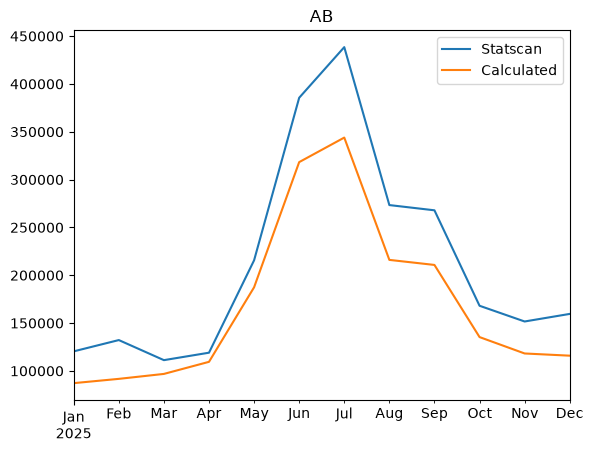

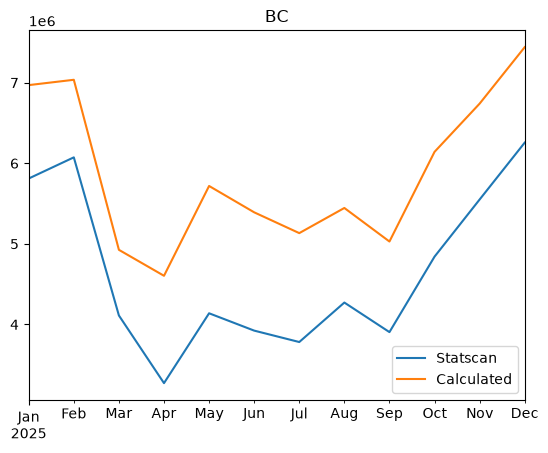

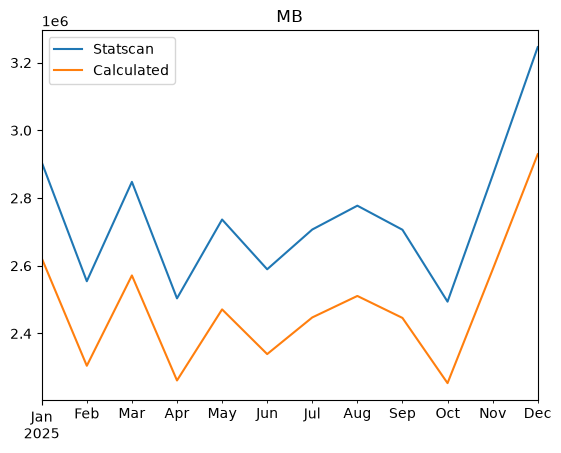

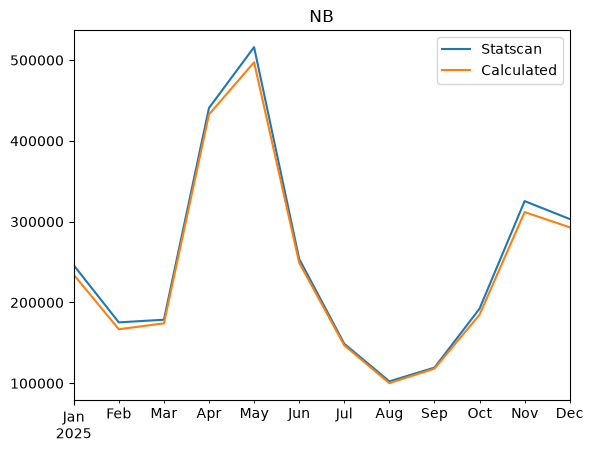

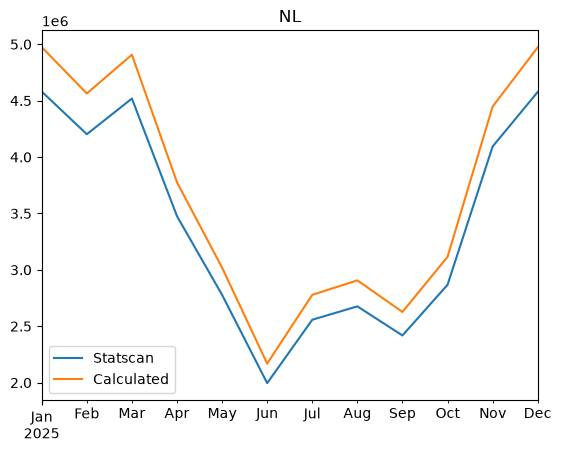

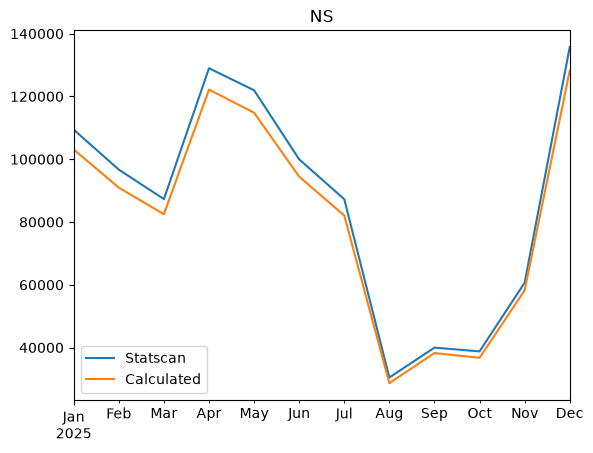

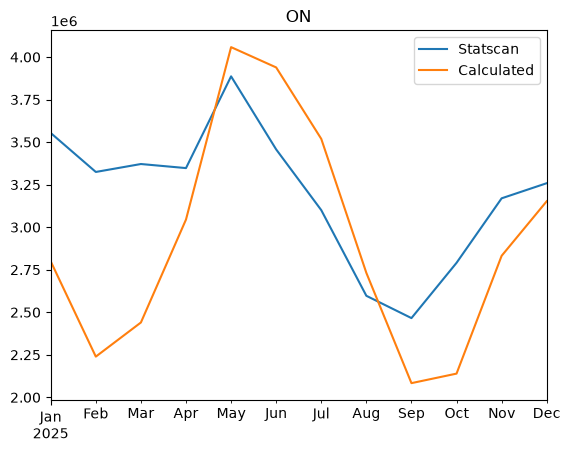

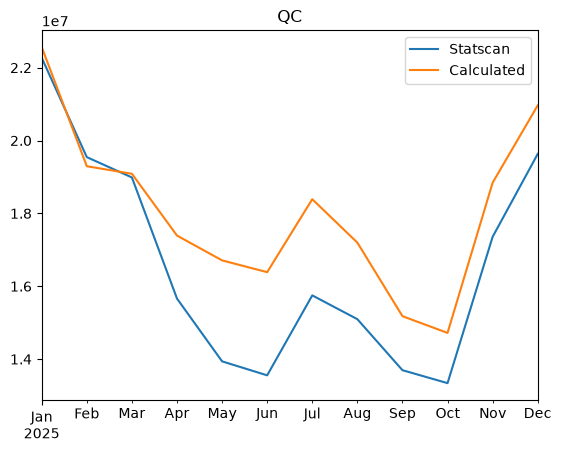

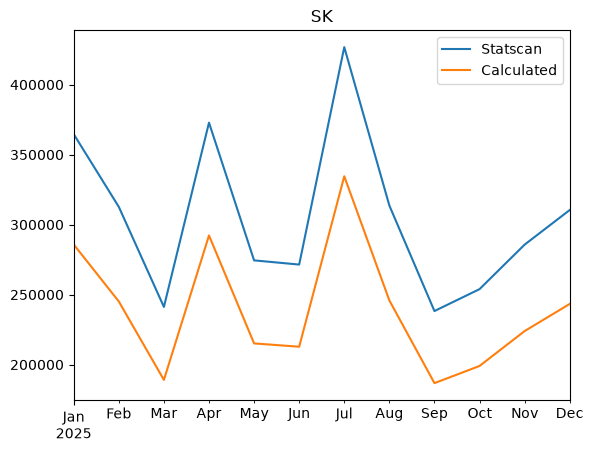

In [13]:
statscan_output = hydro_output.pivot(columns='province', values='VALUE')

grouped_ror['province'] = grouped_ror.bus.str[:2]
gen_province_map = grouped_ror.province.to_dict()
calculated_output = grouped_ror_cf.multiply(grouped_ror.p_nom).rename(columns=gen_province_map).T.groupby(level=0).sum().T.resample('ME').sum()
calculated_output.columns = calculated_output.columns.str[:2]

df['province'] = df.bus.str[:2]
gen_province_map = df.province.to_dict()
calc_inflows = inflows.rename(columns=gen_province_map).T.groupby(level=0).sum().T.resample('ME').sum()

calculated_output = pd.concat([calc_inflows, calculated_output], axis=1)
calculated_output = calculated_output.T.groupby(calculated_output.columns).sum().T

sum_stats = 0
sum_calc = 0
for prov in statscan_output.columns:
    if prov == 'PE':
        continue
    else:
        print(prov)
        print(statscan_output[prov].sum() - calculated_output[prov].sum())
        fig, ax = plt.subplots()
        statscan_output[prov].plot(ax=ax)
        calculated_output[prov].plot(ax=ax)
        ax.set_title(prov)
        ax.legend(['Statscan', 'Calculated'])
        sum_stats += statscan_output[prov].sum()
        sum_calc += calculated_output[prov].sum()

print(f'For {DATA_YEAR}: Statcan total ({sum_stats/1000000} TWh), Calculated total ({sum_calc/1000000} TWh)')
print(f'Difference is {(sum_calc/sum_stats - 1)*100}%')
